## Setup and Configuration

In [50]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
c = 'coral'
c1 = 'yellowgreen'
base_c = 'aqua'

plt.rcParams['text.usetex'] = False
sns.set(style="ticks")
plt.rc('font', family='serif')
#plt.rc('font', serif='Times New Roman')

yaxisfont = 32
bigfont   = 20
medfont   = 20
smallfont = 17

plt.rcParams['xtick.labelsize']=medfont
plt.rcParams['ytick.labelsize']=medfont

#sns.set_style('ticks', {'font.family':'serif', 'font.serif':'Times New Roman', 'font.size': 16})
sns.set_palette("muted")

ticks_fontsize = 18
label_fontsize = 20
cbar_fontsize = 18


In [52]:
# Configuration parameters
k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.001] 
sub_sampling_range = [ 256, 128, 64, 32, 16, 8, 4, 2, 1]  ##4096, 2048, 1024, 512,

# Calculate actual data numbers based on subsample ratio
# Total data amount is 32768, subsample ratio determines how much is used
total_data = 32768
data_number_range = [str(total_data // subsample) for subsample in sub_sampling_range]

seed_range = [2021, 2022, 2023, 2024, 2025]

# Base directory for Hessian results
base_hessian_dir = './hessian_analysis/hessian_analysis_old'

# Hessian metrics to analyze
hessian_metrics = ['trace', 'eigenval_max', 'avg_curvature', 'eigenval_to_trace_ratio']

print(f"Configuration loaded:")
print(f"  K ranges: {len(k_ranges)} settings")
print(f"  Subsample ranges: {len(sub_sampling_range)} settings")
print(f"  Actual data numbers: {data_number_range}")
print(f"  Seeds: {len(seed_range)} seeds")
print(f"  Hessian metrics: {hessian_metrics}")

Configuration loaded:
  K ranges: 8 settings
  Subsample ranges: 9 settings
  Actual data numbers: ['128', '256', '512', '1024', '2048', '4096', '8192', '16384', '32768']
  Seeds: 5 seeds
  Hessian metrics: ['trace', 'eigenval_max', 'avg_curvature', 'eigenval_to_trace_ratio']


In [53]:
# Create k_range labels for visualization
k_range_list = []
for k_range in k_ranges:
    if k_range[0]>=10.0:
        k_range_list.append(f'{int(k_range[0])}-')
    else:
        k_range_list.append(f'{k_range[0]}-')

print(f"K-range labels: {k_range_list}")


K-range labels: ['1.0-', '2.5-', '5.0-', '10-', '20-', '30-', '50-', '100-']


In [54]:
	
def parse_hessian_file(file_path):
    """
    Parse Hessian result file and extract metrics.
    
    Expected format:
    trace: 43992.72363281
    avg_curvature: 0.04188503
    eigenval_max: 47161.54687500
    sharpness_trace: 43992.72363281
    sharpness_eigenval: 47161.54687500
    eigenval_to_trace_ratio: 1.07203062
    """
    results = {}
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                line = line.strip()
                if ':' in line and not line.startswith('=') and not line.startswith('-'):
                    key, value = line.split(':', 1)
                    key = key.strip()
                    value = value.strip()
                    
                    # Convert to appropriate types
                    if key in ['trace', 'avg_curvature', 'eigenval_max', 'sharpness_trace', 
                              'sharpness_eigenval', 'eigenval_to_trace_ratio']:
                        try:
                            results[key] = float(value)
                        except ValueError:
                            results[key] = value
                    elif key in ['Model parameters']:
                        # Handle comma-separated numbers
                        try:
                            results[key] = int(value.replace(',', ''))
                        except ValueError:
                            results[key] = value
                    elif key in ['Computation time']:
                        try:
                            # Extract numeric value from "XX.XX seconds"
                            results[key] = float(value.split()[0])
                        except (ValueError, IndexError):
                            results[key] = value
                    elif key in ['Checkpoint epoch', 'Batches processed']:
                        try:
                            results[key] = int(value)
                        except ValueError:
                            results[key] = value
                    else:
                        results[key] = value
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None
    
    return results

# Test the parser with the example file if it exists
test_file = "hessian_analysis/expts_eps75/poisson_scale_k2.5_5.0_val1024_1M/hessian_analysis/bsz128_lr0.001_subsample1/seed2022/hessian_sharpness_results.txt"
if os.path.exists(test_file):
    test_result = parse_hessian_file(test_file)
    print("Test parsing result:")
    for key, value in test_result.items():
        print(f"  {key}: {value}")
else:
    print(f"Test file not found: {test_file}")

Test file not found: hessian_analysis/expts_eps75/poisson_scale_k2.5_5.0_val1024_1M/hessian_analysis/bsz128_lr0.001_subsample1/seed2022/hessian_sharpness_results.txt


In [55]:
def get_batch_size_for_subsample(subsamples):
    """Get the appropriate batch size for given subsample value."""
    if subsamples == 512:
        return 64
    elif subsamples == 1024:
        return 32
    elif subsamples == 2048:
        return 16
    elif subsamples == 4096:
        return 8
    else:
        return 128  # default batch size

def get_experiment_epochs(subsamples):
    """Get the experiment epochs based on subsample value."""
    if subsamples in [4096, 2048, 1024, 512, 256]:
        return 1000
    elif subsamples == 128:
        return 750
    elif subsamples == 64:
        return 500
    elif subsamples == 32:
        return 300
    elif subsamples == 16:
        return 200
    elif subsamples == 8:
        return 150
    elif subsamples == 4:
        return 100
    elif subsamples == 2:
        return 75
    elif subsamples == 1:
        return 50
    else:
        return 1000  # default

def construct_hessian_file_path(base_dir, k_range, subsample, seed, lr=0.001, method='sharpness'):
    """Construct the path to Hessian result file."""
    # Construct PDE setting name
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    
    # Get epochs and batch size
    epochs = get_experiment_epochs(subsample)
    bsz = get_batch_size_for_subsample(subsample)
    
    # Construct path components
    hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
    seed_setting = f'seed{seed}'
    result_file = f'hessian_{method}_results.txt'
    
    # Full path
    file_path = os.path.join(
        base_dir,
        f'expts_eps{epochs}',
        pde_setting,
        'hessian_analysis',
        hyper_setting,
        seed_setting,
        result_file
    )
    
    return file_path

# Test the path construction
test_path = construct_hessian_file_path(
    base_hessian_dir, [2.5, 5.0], 1, 2022
)
print(f"Constructed path: {test_path}")
print(f"File exists: {os.path.exists(test_path)}")

Constructed path: ./hessian_analysis/hessian_analysis_old/expts_eps50/poisson_scale_k2.5_5.0_val1024_1M/hessian_analysis/bsz128_lr0.001_subsample1/seed2022/hessian_sharpness_results.txt
File exists: True


In [56]:
def load_hessian_statistics(metric='trace', aggregation='mean', method='sharpness'):
    """
    Load Hessian statistics across all configurations.
    
    Args:
        metric: 'trace', 'eigenval_max', 'avg_curvature', 'eigenval_to_trace_ratio'
        aggregation: 'mean', 'std', 'min', 'max' - how to aggregate across seeds
        method: 'sharpness', 'hutchinson', etc.
    
    Returns:
        Dictionary with Hessian statistics organized by configuration
    """
    hessian_stats = {}
    
    print(f"Processing {len(seed_range)} seeds: {seed_range}")
    
    for k_range in k_ranges:
        pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
        hessian_stats[pde_setting] = {}
        
        for subsample in sub_sampling_range:
            bsz = get_batch_size_for_subsample(subsample)
            lr = lr_range[0]
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
            
            metric_values_by_seed = []
            
            # Load results for all seeds
            for seed in seed_range:
                file_path = construct_hessian_file_path(
                    base_hessian_dir, k_range, subsample, seed, lr, method
                )
                
                if os.path.exists(file_path):
                    result = parse_hessian_file(file_path)
                    if result and metric in result:
                        metric_values_by_seed.append(result[metric])
            
            # Aggregate the values
            if metric_values_by_seed:
                if aggregation == 'mean':
                    agg_value = np.mean(metric_values_by_seed)
                elif aggregation == 'std':
                    agg_value = np.std(metric_values_by_seed)
                elif aggregation == 'min':
                    agg_value = np.min(metric_values_by_seed)
                elif aggregation == 'max':
                    agg_value = np.max(metric_values_by_seed)
                else:
                    agg_value = np.mean(metric_values_by_seed)
                
                hessian_stats[pde_setting][hyper_setting] = {
                    f'{metric}_{aggregation}': agg_value,
                    'num_seeds': len(metric_values_by_seed),
                    'all_values': metric_values_by_seed
                }
            else:
                # No data found
                hessian_stats[pde_setting][hyper_setting] = {
                    f'{metric}_{aggregation}': np.nan,
                    'num_seeds': 0,
                    'all_values': []
                }
    
    return hessian_stats

# Load Hessian statistics for different metrics


# print("Loading Average Curvature statistics...")
# avg_curvature_stats = load_hessian_statistics(metric='avg_curvature', aggregation='mean')

# print("Loading Eigenvalue-to-Trace Ratio statistics...")
# ratio_stats = load_hessian_statistics(metric='eigenval_to_trace_ratio', aggregation='mean')

print("Data loading completed!")

Data loading completed!


In [57]:
def create_hessian_heatmap(hessian_stats, metric, aggregation='mean', figsize=(10, 8), 
                          save_path=None, use_log_scale=False):
    """
    Create a 2D heatmap of Hessian metric values.
    
    Args:
        hessian_stats: Dictionary with Hessian statistics
        metric: 'trace', 'eigenval_max', 'avg_curvature', 'eigenval_to_trace_ratio'
        aggregation: 'mean', 'std', etc. for title and data access
        figsize: Figure size tuple
        save_path: Optional path to save the figure
        use_log_scale: Whether to use log scale for the metric
    """
    # Initialize the heatmap matrix
    hessian_matrix = np.full((len(sub_sampling_range), len(k_ranges)), np.nan)
    
    # Fill the matrix
    for i, subsample in enumerate(sub_sampling_range):
        for j, k_range in enumerate(k_ranges):
            pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
            bsz = get_batch_size_for_subsample(subsample)
            lr = lr_range[0]
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
            
            if (pde_setting in hessian_stats and 
                hyper_setting in hessian_stats[pde_setting] and
                f'{metric}_{aggregation}' in hessian_stats[pde_setting][hyper_setting]):
                value = hessian_stats[pde_setting][hyper_setting][f'{metric}_{aggregation}']
                if use_log_scale and value > 0:
                    hessian_matrix[i, j] = np.log10(value)
                else:
                    hessian_matrix[i, j] = value
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Choose colormap based on metric
    if metric in ['trace', 'eigenval_max']:
        # Higher values indicate sharper loss landscape (potentially worse)
        cmap = 'viridis_r'
    elif metric == 'avg_curvature':
        # Average curvature - higher can be good or bad depending on context
        cmap = 'viridis'
    elif metric == 'eigenval_to_trace_ratio':
        # Ratio close to 1 means eigenvalues are similar, higher means more concentrated
        cmap = 'RdYlBu_r'
    else:
        cmap = 'viridis'
    
    im = plt.imshow(hessian_matrix, aspect='auto', cmap=cmap, origin='lower')
    
    # Add colorbar
    cbar = plt.colorbar(im)
    label_suffix = f" (Log₁₀)" if use_log_scale else ""
    cbar.set_label(f"{metric.replace('_', ' ').title()} ({aggregation.capitalize()}){label_suffix}", 
                   fontsize=medfont)
    
    # Set ticks and labels
    plt.xticks(ticks=np.arange(len(k_range_list)), labels=k_range_list, fontsize=medfont)
    plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
    
    # Set labels and title
    plt.xlabel("PDE Settings (K-range)", fontsize=medfont)
    plt.ylabel("Number of Training Samples", fontsize=medfont)
    title = f"Hessian {metric.replace('_', ' ').title()} - {aggregation.capitalize()}"
    if use_log_scale:
        title += " (Log Scale)"
    plt.title(title, fontsize=yaxisfont)
    
    # Add text annotations with values
    # for i in range(hessian_matrix.shape[0]):
    #     for j in range(hessian_matrix.shape[1]):
    #         if not np.isnan(hessian_matrix[i, j]):
    #             # Choose text color based on background
    #             text_color = 'white' if hessian_matrix[i, j] < np.nanmean(hessian_matrix) else 'black'
    #             if use_log_scale:
    #                 plt.text(j, i, f'{hessian_matrix[i, j]:.1f}', 
    #                         ha='center', va='center', color=text_color, fontsize=9)
    #             else:
    #                 # Format based on magnitude
    #                 if abs(hessian_matrix[i, j]) >= 1000:
    #                     plt.text(j, i, f'{hessian_matrix[i, j]:.0f}', 
    #                             ha='center', va='center', color=text_color, fontsize=8)
    #                 elif abs(hessian_matrix[i, j]) >= 1:
    #                     plt.text(j, i, f'{hessian_matrix[i, j]:.1f}', 
    #                             ha='center', va='center', color=text_color, fontsize=9)
    #                 else:
    #                     plt.text(j, i, f'{hessian_matrix[i, j]:.3f}', 
    #                             ha='center', va='center', color=text_color, fontsize=9)
    #         else:
    #             plt.text(j, i, 'N/A', ha='center', va='center', color='gray', fontsize=9)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to: {save_path}")
    
    plt.show()
    
    return im, hessian_matrix

def print_hessian_statistics(hessian_stats, metric):
    """Print summary statistics of Hessian metric values."""
    all_values = []
    missing_count = 0
    total_count = 0
    
    for pde_setting in hessian_stats:
        for hyper_setting in hessian_stats[pde_setting]:
            total_count += 1
            values = hessian_stats[pde_setting][hyper_setting].get('all_values', [])
            if values:
                all_values.extend(values)
            else:
                missing_count += 1
    
    if all_values:
        print(f"\n{metric.replace('_', ' ').title()} Statistics:")
        print(f"  Total configurations: {total_count}")
        print(f"  Missing data: {missing_count}")
        print(f"  Available values: {len(all_values)}")
        print(f"  Mean: {np.mean(all_values):.4f}")
        print(f"  Std: {np.std(all_values):.4f}")
        print(f"  Min: {np.min(all_values):.4f}")
        print(f"  Max: {np.max(all_values):.4f}")
        print(f"  Median: {np.median(all_values):.4f}")
        
        # Metric-specific interpretations
        if metric == 'trace':
            print(f"  Range: {np.max(all_values) - np.min(all_values):.4f}")
        elif metric == 'eigenval_max':
            print(f"  Range: {np.max(all_values) - np.min(all_values):.4f}")
        elif metric == 'eigenval_to_trace_ratio':
            high_concentration = sum(1 for val in all_values if val > 2.0)
            print(f"  High eigenvalue concentration (>2.0): {high_concentration}/{len(all_values)} ({100*high_concentration/len(all_values):.1f}%)")
    else:
        print(f"No {metric} values found!")

## Hessian Trace Analysis


Trace Statistics:
  Total configurations: 72
  Missing data: 0
  Available values: 360
  Mean: 5800.5334
  Std: 3454.5697
  Min: 1567.5279
  Max: 26862.9659
  Median: 4872.4625
  Range: 25295.4381
Loading Hessian Trace statistics...
Processing 5 seeds: [2021, 2022, 2023, 2024, 2025]


Heatmap saved to: ./plots/hessian_trace_heatmap.png


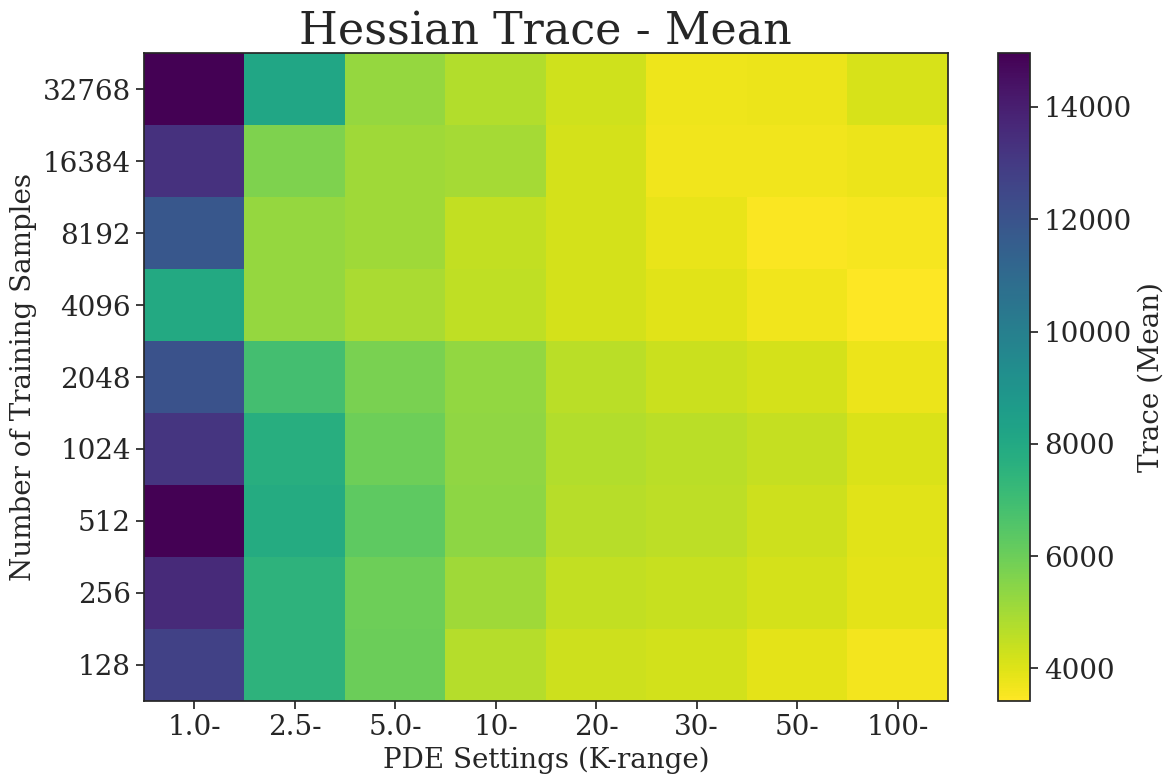

In [58]:
# Print statistics for Hessian trace
print_hessian_statistics(trace_stats, 'trace')

# Create heatmap for Hessian trace (use log scale due to large values)
os.makedirs('./plots', exist_ok=True)

print("Loading Hessian Trace statistics...")
trace_stats = load_hessian_statistics(metric='trace', aggregation='mean')

trace_im, trace_matrix = create_hessian_heatmap(
    trace_stats, 
    'trace', 
    aggregation='mean',
    figsize=(12, 8),
    save_path='./plots/hessian_trace_heatmap.png',
    use_log_scale=False
)


Trace Statistics:
  Total configurations: 72
  Missing data: 0
  Available values: 360
  Mean: 5800.5334
  Std: 3454.5697
  Min: 1567.5279
  Max: 26862.9659
  Median: 4872.4625
  Range: 25295.4381
Loading Hessian Trace statistics...
Processing 5 seeds: [2021, 2022, 2023, 2024, 2025]
Heatmap saved to: ./plots/hessian_trace_heatmap.png


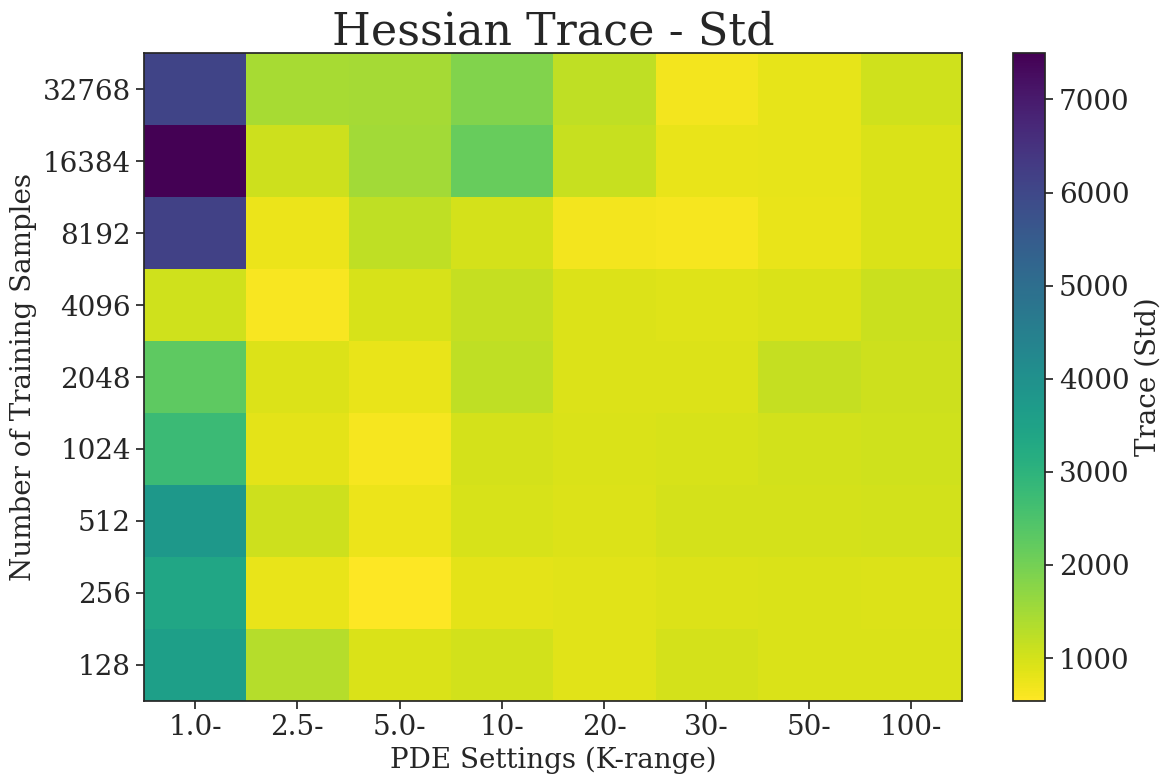

In [59]:
# Print statistics for Hessian trace
print_hessian_statistics(trace_stats, 'trace')

# Create heatmap for Hessian trace (use log scale due to large values)
os.makedirs('./plots', exist_ok=True)

print("Loading Hessian Trace statistics...")
trace_stats = load_hessian_statistics(metric='trace', aggregation='std')

trace_im, trace_matrix = create_hessian_heatmap(
    trace_stats, 
    'trace', 
    aggregation='std',
    figsize=(12, 8),
    save_path='./plots/hessian_trace_heatmap.png',
    use_log_scale=False
)